In [24]:
#!/usr/bin/env python3
# hyper_mmca_each_graph.py
"""
方案 B：每次生成一张新的 3-uniform 超图并在其上运行一次 MMCA（共 R 次）。
最终保存 rho_runs (R x (T+1)) 与 mean_rho_mmca 到 CSV（可选）。
运行：python hyper_mmca_each_graph.py
"""

import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from time import time

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]

        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def compute_qi(self, p, Theta, beta_d):
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        qi = np.zeros(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            qi[node] = 1.0 - prod_val
        return np.clip(qi, 0.0, 1.0)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0)

    def run_mmca(self, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                 T=100, init_frac=0.01, verbose=False):
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_ts = []
        theta_ts = []
        for t in range(T):
            rho_ts.append(p.mean())
            theta_ts.append(Theta.mean())
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next
            if verbose and (t % 20 == 0):
                print(f"[MMCA] t={t:3d}  rho={rho_ts[-1]:.4f}  ⟨Θ⟩={theta_ts[-1]:.4f}")
        rho_ts.append(p.mean()); theta_ts.append(Theta.mean())
        return np.array(rho_ts), np.array(theta_ts)

# -------------------- 参数（可修改） --------------------
n = 1500
kappa = 6.0
beta = 0.35
mu = 0.1
T = 500
init_frac = 0.3
seed = 12345       # 基础种子（用于生成每次不同的网络）；设为 None 则不固定
eta = 0.6
gamma = 0.02

R = 10  # 重复次数：每次生成新网络并运行一次 MMCA

# -------------------- 主循环：每次生成新超图并在其上运行一次 MMCA（与 MC 部分写法一致） --------------------
print("Starting: each repeat generates a new hypergraph and runs one MMCA on it.")
rho_runs = np.zeros((R, T+1), dtype=float)
theta_runs = np.zeros((R, T+1), dtype=float)

t0 = time()
for r in range(R):
    gen_seed = None if seed is None else (seed + r)   # 生成超图的种子（可复现）
    hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed, batch_size=3000)
    model = HyperSISModel(hyperedges, n)

    # MMCA 是确定性的（给定 init_frac、Theta 初始值等），因此无需额外 run_seed。
    rho_r, theta_r = model.run_mmca(beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                    T=T, init_frac=init_frac, verbose=False)

    # 保存到预分配数组
    rho_runs[r] = rho_r
    theta_runs[r] = theta_r

    if (r+1) % 10 == 0 or (r+1) == R:
        elapsed = time() - t0
        print(f"  Completed {r+1}/{R} runs, elapsed {elapsed:.1f}s")
    # print("实际执行次数:", r+1)

t_mc = time() - t0
print(f"All {R} independent-graph MMCA runs done in {t_mc:.2f}s")

# -------------------- 统计量：均值（不计算置信区间） --------------------
mean_rho_mmca = rho_runs.mean(axis=0)
mean_S_mmca = 1.0 - mean_rho_mmca

theta_mean_mmca = theta_runs.mean(axis=0)

# -------------------- 保存数据到 CSV --------------------
pd.DataFrame(rho_runs).to_csv("./rho_runs_mmca_each_graph.csv", index=False, header=False)

ts = np.arange(T+1)
pd.DataFrame({
    'time': ts,
    'mean_rho_mmca': mean_rho_mmca,
    'theta_mean_mmca': theta_mean_mmca,
}).to_csv("./mean_rho_mmca_each_graph.csv", index=False, float_format="%.6f")

print("Saved rho_runs_mmca_each_graph.csv and mean_rho_mmca_each_graph.csv")

# -------------------- 查看形状（调试用） --------------------
print("rho_runs.shape =", rho_runs.shape)



Starting: each repeat generates a new hypergraph and runs one MMCA on it.
  Completed 10/10 runs, elapsed 13.7s
All 10 independent-graph MMCA runs done in 13.70s
Saved rho_runs_mmca_each_graph.csv and mean_rho_mmca_each_graph.csv
rho_runs.shape = (10, 501)


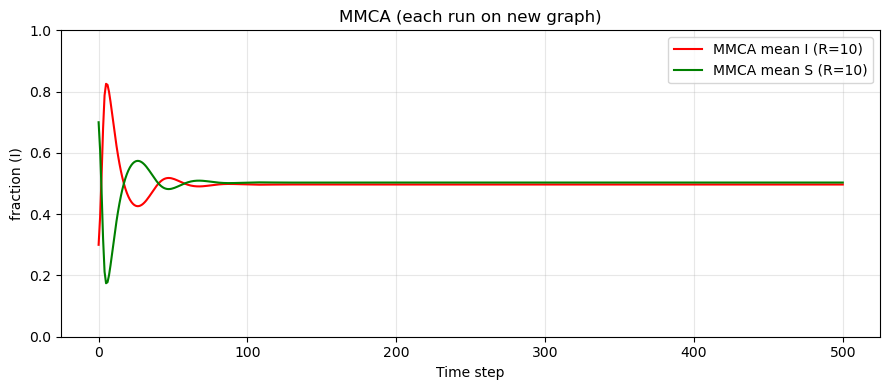

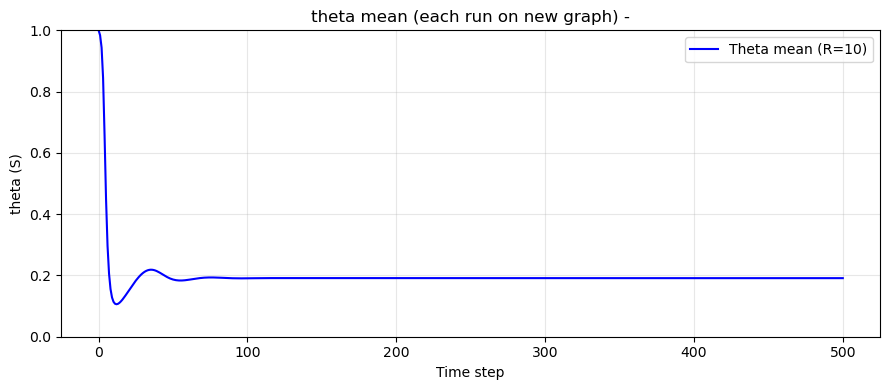

Final infected (mean over graphs): 0.4968
Done.


In [25]:

# 读取数据 
# 读取 rho_runs
rho_df = pd.read_csv("./rho_runs_mmca_each_graph.csv")
rho_runs = rho_df.values  # 转回 NumPy 数组


# 读取 mean_rho_mmca
mean_df = pd.read_csv("./mean_rho_mmca_each_graph.csv")
ts = mean_df['time'].values
mean_rho_mmca = mean_df['mean_rho_mmca'].values
theta_mean_mmca = mean_df['theta_mean_mmca'].values

# Susceptible fractions
mean_S_mmca = 1 - mean_rho_mmca

# -------------------- 绘图：跨图平均 I(t) 与 S(t) --------------------
plt.figure(figsize=(9,4))
plt.plot(ts, mean_rho_mmca, label=f'MMCA mean I (R={R})', color='red')
plt.plot(ts, mean_S_mmca, label=f'MMCA mean S (R={R})', color='green')
plt.xlabel("Time step")
plt.ylabel("fraction (I)")

plt.ylim(0.0, 1.0)
plt.title("MMCA (each run on new graph)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,4))
plt.plot(ts, theta_mean_mmca, label=f'Theta mean (R={R})', color='blue')
plt.xlabel("Time step")
plt.ylabel("theta (S)")

plt.ylim(0.0, 1.0)
plt.title("theta mean (each run on new graph) -")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


print(f"Final infected (mean over graphs): {mean_rho_mmca[-1]:.4f}")
print("Done.")
